In [1]:
import matplotlib.pyplot as plt
import numpy as np

## 老虎机

### 老虎机

In [2]:
class Bandit:
    def __init__(self, arms=10):
        self.rates = np.random.rand(arms)  # 每台机器的胜率

    def play(self, arm):
        rate = self.rates[arm]
        if rate > np.random.rand():
            return 1
        else:
            return 0

In [3]:
bandit = Bandit()
for i in range(3):
    print(bandit.play(0))

1
1
1


### 智能体

In [4]:
class Agent:
    def __init__(self, epsilon, action_size=10):
        self.epsilon = epsilon
        self.Qs = np.zeros(action_size)
        self.ns = np.zeros(action_size)

    def update(self, action, reward):
        self.ns[action] += 1
        self.Qs[action] += (reward - self.Qs[action]) / self.ns[action]

    def get_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, len(self.Qs))
        return np.argmax(self.Qs)

### 运行

In [5]:
steps = 1000
epsilon = 0.1
bandit = Bandit()
agent = Agent(epsilon)
total_reward = 0
total_rewards = []
rates = []

for step in range(steps):
    action = agent.get_action()  # ①选择行动
    reward = bandit.play(action)  # ②实际去玩，获得奖励
    agent.update(action, reward)  # ③从行动和奖励中学习
    total_reward += reward
    total_rewards.append(total_reward)
    rates.append(total_reward / (step + 1))

print(total_reward)

880


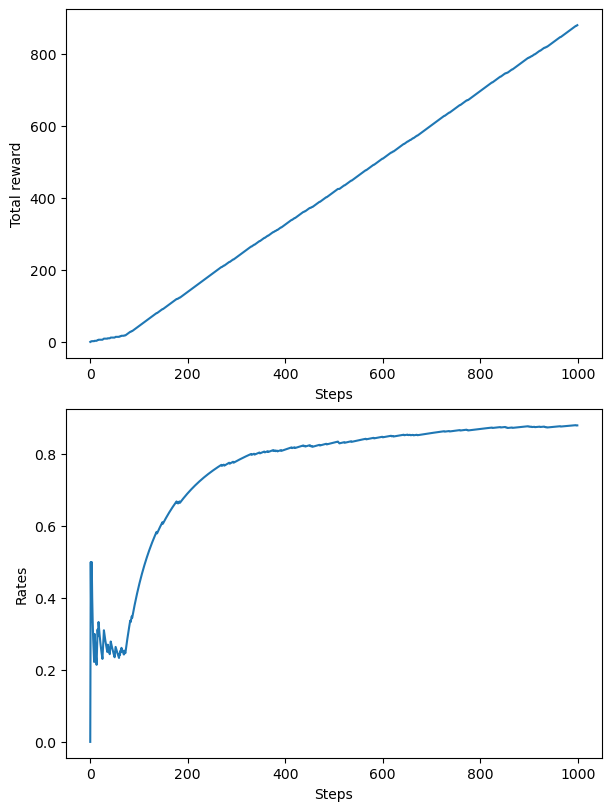

In [10]:
_, axes = plt.subplots(2, 1, figsize=(6, 8), constrained_layout=1)

axes[0].set(xlabel="Steps", ylabel="Total reward")
axes[0].plot(total_rewards)

axes[1].set(xlabel="Steps", ylabel="Rates")
axes[1].plot(rates)

plt.savefig("../images/ml-rl-bandit-stats.png")